## Librerias

In [1]:
import pandas as pd
import numpy as np

# Preprocesamiento
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelo
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

## Datos

In [2]:
df = pd.read_csv("dfSegmentado.csv")

# Eliminar columnas irrelevantes
df = df.drop(columns=["ID", "Identificador"], errors="ignore")

X = df.drop("Segmento", axis=1)
y = df["Segmento"]

## Preprocesamiento

In [3]:
categoricas = X.select_dtypes(include=["object"]).columns
numericas = X.select_dtypes(include=["int64", "float64"]).columns

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
        ("num", "passthrough", numericas)
    ]
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

In [8]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [9]:
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,               # cantidad de combinaciones
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

## Entrenamiento

In [10]:
random_search.fit(X_train, y_train)

print("Mejores parámetros:")
print(random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10}


In [11]:
best_model = random_search.best_estimator_

## Evaluacion

In [12]:
y_pred = best_model.predict(X_test)

In [13]:
print("Train Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy:", best_model.score(X_test, y_test))

Train Accuracy: 0.6425472575147195
Test Accuracy: 0.533457249070632


In [14]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           A       0.42      0.40      0.41       394
           B       0.43      0.33      0.37       372
           C       0.58      0.59      0.59       394
           D       0.63      0.76      0.69       454

    accuracy                           0.53      1614
   macro avg       0.52      0.52      0.51      1614
weighted avg       0.52      0.53      0.52      1614



## Matriz

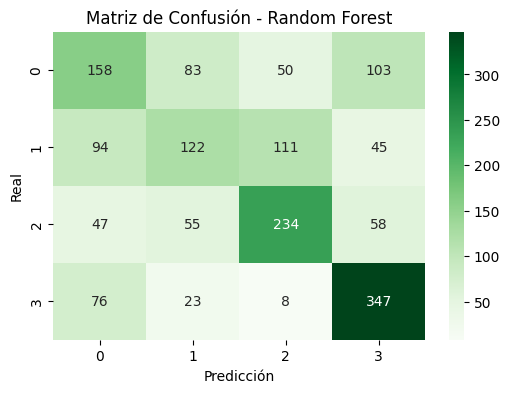

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [16]:
# Extraer modelo interno
rf_model = best_model.named_steps["model"]

# Nombres de features transformadas
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp.head(10))

num__Edad                    0.273642
num__Tamano_Familiar         0.087382
num__Experiencia_Laboral     0.081929
cat__Puntuacion_Gasto_Low    0.079568
cat__Profesion_Healthcare    0.077184
cat__Profesion_Artist        0.069202
cat__Graduado_No             0.047886
cat__Estado_Civil_No         0.045115
cat__Graduado_Yes            0.040013
cat__Estado_Civil_Yes        0.039962
dtype: float64


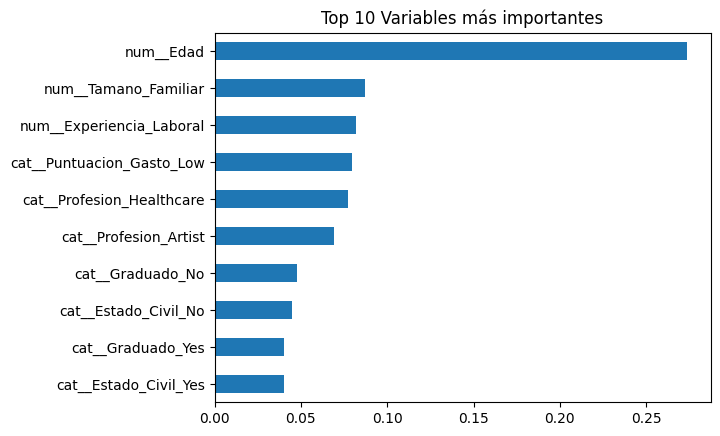

In [17]:
feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Variables más importantes")
plt.gca().invert_yaxis()
plt.show()